

<center><font size=10>Generative AI for Business Applications</center></font>
<center><font size=6>Embeddings to Transformers</center></font>

<center><img src="https://ideamaker.agency/wp-content/uploads/2024/08/The-Benefits-of-AI-Sentiment-Analysis-in-Businesses.webp" width="720"/></center>

<center><font size=5>Product Reviews Sentimenit Analysis </center></font>

## Problem Statement

### **Business Context**

*  Customers share their opinions about products through reviews.
*  This project helps businesses understand whether customers are happy or unhappy with a product by analyzing their reviews

### **Objective**

*  The main goal is to understand customer opinions from product reviews.
*  It helps identify positive and negative feedback so businesses can improve their products and customer experience.

### Data Description

* **Product ID**: An exclusive identification number for each product

* **Product Review**: Insights and opinions shared by customers about the product

* **Sentiment**: Sentiment associated with the product review, indicating whether the review expresses a positive, negative, or neutral sentiment.

* The dataset has 1007 rows and 3 columns.

## Importing the necessary libraries

We install specific tested library versions to ensure compatibility and avoid errors during development.


In [ ]:
# installing the libraries for transformers
!pip install sentence-transformers

Note:
- After running the above cell, kindly restart the runtime (for Google Colab) and run all cells sequentially from the next cell.


### **Libraries Used**

* **Pandas** – Used to load, clean, organize, and analyze the review data.
* **NumPy** – Used for numerical operations and efficient data handling.
* **Matplotlib** – Used to create charts and visualize the data.
* **Seaborn** – Used to create statistical graphs and attractive visualizations.
* **Scikit-learn** – Used to train and evaluate the machine learning models.
* **Sentence Transformers** – Used to convert customer reviews into meaningful numerical representations.


In [ ]:
import pandas as pd
import numpy as np
import warnings

from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

warnings.filterwarnings('ignore')

## Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/Dataset/GenAIDataset/Product_Reviews.csv")

## Data Overview

In [ ]:
# Display the number of rows and columns in the movie_data
data.shape

(1005, 3)

In [ ]:
# Display the first 5 rows of the
data.head(5)

,Product ID,Product Review,Sentiment
0,AVpe7AsMilAPnD_xQ78G,I initially had trouble deciding between the p...,POSITIVE
1,AVpe7AsMilAPnD_xQ78G,Allow me to preface this with a little history...,POSITIVE
2,AVpe7AsMilAPnD_xQ78G,I am enjoying it so far. Great for reading. Ha...,POSITIVE
3,AVpe7AsMilAPnD_xQ78G,I bought one of the first Paperwhites and have...,POSITIVE
4,AVpe7AsMilAPnD_xQ78G,I have to say upfront - I don't like coroporat...,POSITIVE


* There are no missing values in the data

In [ ]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

* There are 2 duplicate values in the dataset.
* We'll drop them.

In [ ]:
# dropping duplicate values
data = data.drop_duplicates().reset_index(drop=True)

data.duplicated().sum()

np.int64(0)

**NOTE:** We reset the index after dropping duplicates to maintain a clean, continuous index for the updated DataFrame.


In [ ]:
# Reset the index of dataframe
data = data.reset_index(drop=True)

## Exploratory Data Analysis (EDA)

* EDA (Exploratory Data Analysis) means understanding the data before using it.
* It helps us find useful information and patterns in the data.
* It helps us identify missing or incorrect information.
* Charts and simple calculations make the data easier to understand.
* Overall, EDA helps us make better decisions using the data.

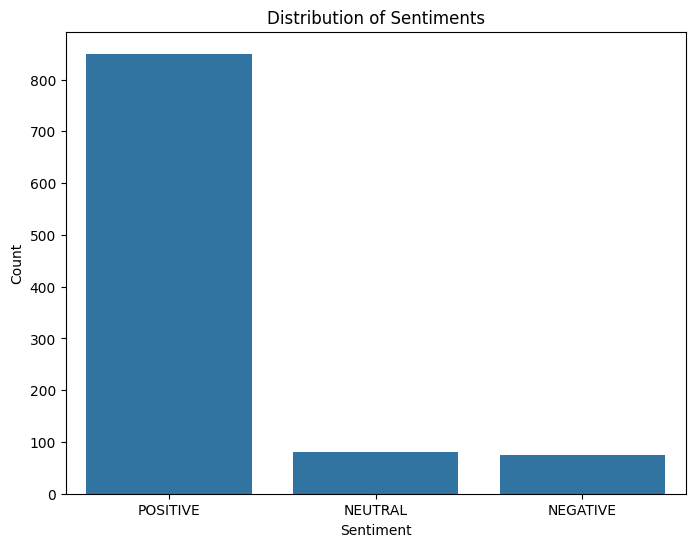

In [ ]:
# Visualize the distribution of sentiments in the dataset
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=data)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

**Observation:**
- The dataset contains a majority of positive reviews (\~850), with neutral and negative reviews being significantly fewer, around 75 each.


## Defining the Sentence Transformer  Model

* A Sentence Transformer Model helps a computer understand the meaning of sentences.
* It converts sentences into numbers (embeddings) that represent their meaning.
* This allows us to compare two sentences and check how similar they are.
* For example, “I like cars” and “I love automobiles” have different words but similar meanings.
* So, Sentence Transformers are useful for text similarity, search, question answering, and recommendation systems

In [ ]:
# Load the pre-trained SentenceTransformer model all-MiniLM-L6-v2

# defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Generate embeddings for the `Product Review' in the dataset.

print(type(data['Product Review']))

<class 'pandas.core.series.Series'>


In [ ]:
embedding_matrix = model.encode(
    data['Product Review'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

## Data Pre-processing

* Data preprocessing means preparing the data before using it
* It helps to clean and organize the data so that it is easier to understand and use.
* For example, we can remove unwanted data, handle missing values, and correct errors.
* It also helps make the data consistent and ready for analysis or machine learning.
* In simple words: Data preprocessing is like cleaning and preparing the data before cooking a meal

### Splitting the dataset

In [ ]:
#Split the data using embedding_matrix as X and data['Sentiment'] as y, with a 80:20 train-test ratio and maintain the class distribution.

X = embedding_matrix
y = data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
# prompt: Check the shape of the training and testing sets to confirm the split.

print('Shape of training data:', X_train.shape)
print('Shape of testing data:', X_test.shape)
print('Shape of training labels:', y_train.shape)
print('Shape of testing labels:', y_test.shape)

Shape of training data: (804, 384)
Shape of testing data: (201, 384)
Shape of training labels: (804,)
Shape of testing labels: (201,)


## Model Building - Transformers + ML

### **Model Evaluation Criteria**

1. **Accuracy** is used to measure the overall correctness of the model by calculating the proportion of total correct predictions across all sentiment classes.

2. **F1 Score** is used to evaluate the balance between precision and recall, providing a more reliable performance metric, especially in the presence of class imbalance among positive, neutral, and negative sentiments.


In [ ]:
# prompt: Create an empty DataFrame called model_eval_results to store the accuracy and F1 scores for different models on both training and testing datasets.

model_eval_results = pd.DataFrame(columns=['Model', 'Train_Accuracy', 'Train_F1', 'Test_Accuracy', 'Test_F1'])

### Random Forest Classifier

* Random Forest Classifier is a machine learning method used to classify data into different groups.
* It creates many decision trees and combines their results to make a final prediction.
* For example, it can predict whether an email is spam or not spam.
* Using many trees makes the prediction more reliable and accurate than using only one decision tree.

In simple words: Random Forest is like asking many people for their opinion and choosing the answer most of them agree on.

In [ ]:
# Train the model using a Random Forest classifier

# Building the model
rf_transformer = RandomForestClassifier(random_state = 42)

# Fitting on train data
rf_transformer.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# prompt: Evaluate the model on training and testing data and store in model-eval_result

from sklearn.metrics import f1_score

# Evaluate the model on training data
y_train_pred_rf = rf_transformer.predict(X_train)
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_f1_rf = f1_score(y_train, y_train_pred_rf, average='weighted')

# Evaluate the model on testing data
y_test_pred_rf = rf_transformer.predict(X_test)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf, average='weighted')

# Store results
new_row_rf = pd.DataFrame([{
    'Model': 'RandomForest + Transformer',
    'Train_Accuracy': train_accuracy_rf,
    'Train_F1': train_f1_rf,
    'Test_Accuracy': test_accuracy_rf,
    'Test_F1': test_f1_rf
}])

model_eval_results = pd.concat([model_eval_results, new_row_rf], ignore_index=True)

model_eval_results

,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1
0,RandomForest + Transformer,1.0,1.0,0.865672,0.818014


The RandomForest model with Transformer embeddings achieved full training accuracy and F1 score, and performed well on the test set with 86.5% accuracy and an F1 score of 81.8%, indicating good generalization.


### Gradient Boost Classifier

* Gradient Boosting Classifier is a machine learning method used to classify data into different groups.
* It builds many small decision trees one after another.
* Each new tree tries to correct the mistakes made by the previous trees.
* By combining all the trees, it can make a strong and accurate prediction.

In simple words: It is like learning from previous mistakes and improving the answer step by step.


In [ ]:
# prompt: Train the model using a Gradient Boost classifier

# Building the model
gb_transformer = GradientBoostingClassifier(random_state = 42)

# Fitting on train data
gb_transformer.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
# prompt: Evaluate the model on training and testing data and store in model-eval_result

# Evaluate the model on training data
y_train_pred_gb = gb_transformer.predict(X_train)
train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
train_f1_gb = f1_score(y_train, y_train_pred_gb, average='weighted')

# Evaluate the model on testing data
y_test_pred_gb = gb_transformer.predict(X_test)
test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
test_f1_gb = f1_score(y_test, y_test_pred_gb, average='weighted')

# Store results
new_row_gb = pd.DataFrame([{
    'Model': 'GradientBoost + Transformer',
    'Train_Accuracy': train_accuracy_gb,
    'Train_F1': train_f1_gb,
    'Test_Accuracy': test_accuracy_gb,
    'Test_F1': test_f1_gb
}])

model_eval_results = pd.concat([model_eval_results, new_row_gb], ignore_index=True)

model_eval_results

,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1
0,RandomForest + Transformer,1.000000,1.000000,0.865672,0.818014
1,GradientBoost + Transformer,0.998756,0.998752,0.840796,0.803252


The GradientBoost model with Transformer embeddings achieved good training metrics and delivered a test accuracy of 84.07% with an F1 score of 80.3%, indicating slightly lower performance compared to the Random Forest model.


**Note:**
The performance of the classification model can be further improved by exploring additional machine learning techniques and advanced deep learning architectures, such as XGBoost, Support Vector Machines, Sequential neural networks, or fine-tuned transformer-based models.


## Final Model Selection


* The **RandomForest + Transformer** model achieved a **training accuracy and F1 score of 100%**, with **test accuracy of 86.6%** and **F1 score of 81.8%**, reflecting a generalization drop of **13.4% in accuracy** and **18.2% in F1 score**.

* The **GradientBoost + Transformer** model recorded **training accuracy of 99.88%** and **F1 score of 99.87%**, but a slightly lower **test accuracy of 84.1%** and **F1 score of 80.3%**, resulting in a generalization drop of **15.8% in accuracy** and **19.6% in F1 score**.

* Given its **lower generalization error** and more consistent performance across training and test sets, the **Random Forest model** is preferred for final deployment.


# Conclusion

* We analyzed customer review data and categorized sentiments into positive, neutral, and negative, using sentence embeddings generated from a pre-trained Transformer model.

* We trained and evaluated Random Forest and Gradient Boosting models using these embeddings, with Random Forest achieving the best test performance (86.1% accuracy and 81.4% F1 score).

* Moving forward, the model can be continuously improved by incorporating new incoming reviews into the training data, allowing it to adapt to evolving customer language and sentiment trends.


<font size=6 color='blue'>Power Ahead</font>
___